In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRFRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint


In [41]:
df= pd.read_csv('/content/sample_data/train.csv')
df.head(10)

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
5,2013-01-06,1,1,12
6,2013-01-07,1,1,10
7,2013-01-08,1,1,9
8,2013-01-09,1,1,12
9,2013-01-10,1,1,9


# New Section

Check For Null Value in the data sets

In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


Dropping sales and item coloumns

In [43]:
df = df.drop(['store','item'], axis=1)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   sales   913000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 13.9+ MB


Coverting date from object datatype to date time datatype

In [45]:
df['date'] = pd.to_datetime(df['date'])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 13.9 MB


Converting date to month period and then sum the number of items in eachmonth

In [47]:
df['date']=df['date'].dt.to_period("M")
monthly_sales = df.groupby('date').sum().reset_index()

Covert the resulting date column to timestamp datatype

In [48]:
monthly_sales['date']=monthly_sales['date'].dt.to_timestamp()

In [49]:
monthly_sales.head(10)

,date,sales
0,2013-01-01,454904
1,2013-02-01,459417
2,2013-03-01,617382
3,2013-04-01,682274
4,2013-05-01,763242
5,2013-06-01,795597
6,2013-07-01,855922
7,2013-08-01,766761
8,2013-09-01,689907
9,2013-10-01,656587


Visalulization


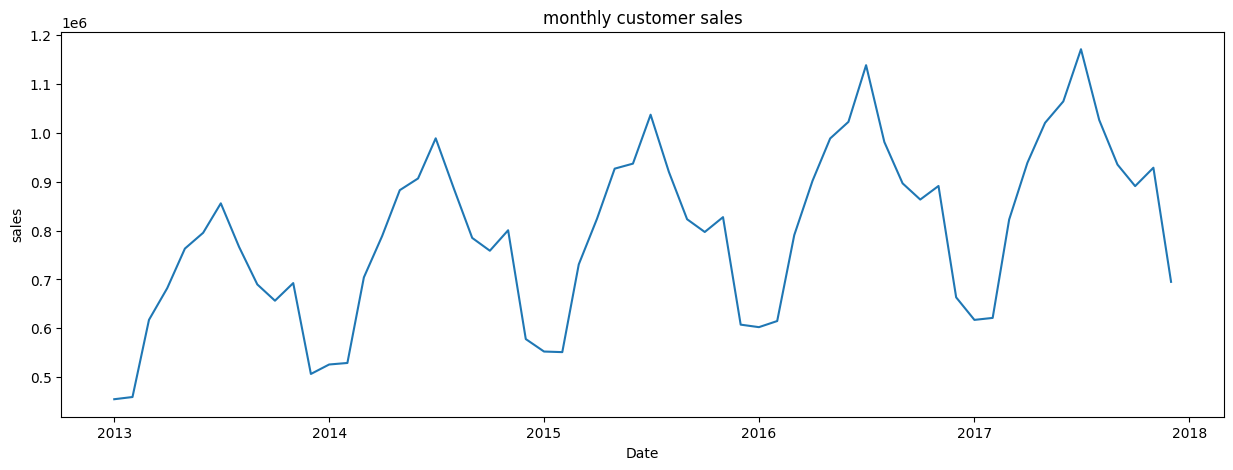

In [50]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales['date'],monthly_sales['sales'])
plt.xlabel("Date")
plt.ylabel("sales")
plt.title("monthly customer sales")
plt.show()

call the difference on the sales columns to makethe sales data stationery

In [51]:
monthly_sales['sales_diff'] = monthly_sales['sales'].diff()
monthly_sales = monthly_sales.dropna()
monthly_sales.head(10)

,date,sales,sales_diff
1,2013-02-01,459417,4513.0
2,2013-03-01,617382,157965.0
3,2013-04-01,682274,64892.0
4,2013-05-01,763242,80968.0
5,2013-06-01,795597,32355.0
6,2013-07-01,855922,60325.0
7,2013-08-01,766761,-89161.0
8,2013-09-01,689907,-76854.0
9,2013-10-01,656587,-33320.0
10,2013-11-01,692643,36056.0


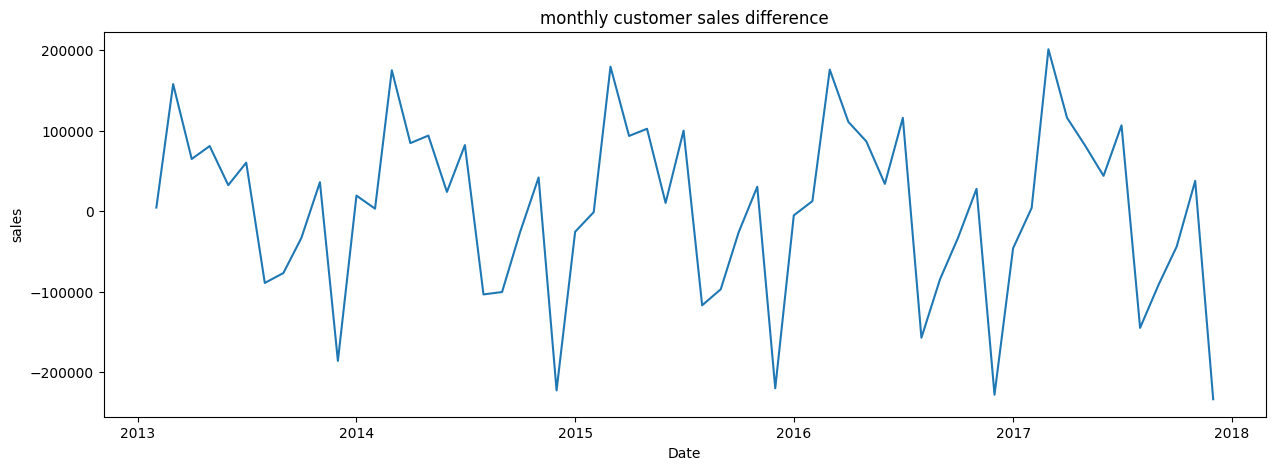

In [52]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales['date'],monthly_sales['sales_diff'])
plt.xlabel("Date")
plt.ylabel("sales")
plt.title("monthly customer sales difference")
plt.show()

dropping off sales and date


In [53]:
supervised_data=monthly_sales.drop(['date','sales'],axis=1)

Preparing the supervised data

In [54]:
for i in range(1,13):
  col_name = 'month_'  +str(i)
  supervised_data[col_name]=supervised_data['sales_diff'].shift(i)
supervised_data = supervised_data.dropna().reset_index(drop=True)
supervised_data.head(10)



,sales_diff,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0,157965.0,4513.0
1,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0,157965.0
2,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0
3,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0
4,23965.0,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0
5,82168.0,23965.0,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0
6,-103414.0,82168.0,23965.0,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0
7,-100472.0,-103414.0,82168.0,23965.0,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0
8,-26241.0,-100472.0,-103414.0,82168.0,23965.0,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0
9,41900.0,-26241.0,-100472.0,-103414.0,82168.0,23965.0,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0


Split the data into test and train

In [55]:
train_data = supervised_data[:-12]
test_data = supervised_data[-12:]
print("train data shpe: ",train_data.shape)
print("test data shpe: ",test_data.shape)



train data shpe:  (35, 13)
test data shpe:  (12, 13)


In [56]:
scaler = MinMaxScaler(feature_range=(-1,1))
scaler.fit(train_data)
train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

In [57]:
X_train, y_train = train_data[:,1:],train_data[:,0:1]
X_test, y_test = test_data[:,1:] , test_data[:,0:1]
y_train = y_train.ravel()
y_test = y_test.ravel()
print("x_train shape: ",X_train.shape)
print("y_train shape: ",y_train.shape)
print("x_test shape: ",X_test.shape)
print("y_test shape: ",y_test.shape)

x_train shape:  (35, 12)
y_train shape:  (35,)
x_test shape:  (12, 12)
y_test shape:  (12,)


prdiction data frame to merge the predicted sales prices of all trained algs

In [58]:
sales_data = monthly_sales['date'][-12:].reset_index(drop=True)
predict_df = pd.DataFrame(sales_data)

In [59]:
act_sales  = monthly_sales['sales'][-13:].to_list()
print(act_sales)

[663411, 617306, 621369, 822667, 938862, 1020686, 1064624, 1171393, 1026403, 935263, 891160, 928837, 695170]


to ceate the linear regression model and predicted output


In [60]:
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)
lr_pred = lr_model.predict(X_test)

In [61]:
lr_pred = lr_pred.reshape(-1,1)
#This is a set matrix - contains the imput features of the test data,and also tehe predicted output
lr_pre_test_set = np.concatenate([lr_pred, X_test],axis=1)
lr_pre_test_set = scaler.inverse_transform(lr_pre_test_set)

In [62]:
result_list=[]
for index in range(0,len(lr_pre_test_set)):
  result_list.append(lr_pre_test_set[index][0] + act_sales[index])
lr_pre_series = pd.Series(result_list,name="Linear prediction")

predict_df = predict_df.merge(lr_pre_series,left_index = True, right_index= True)

In [65]:
from sklearn.metrics import r2_score # Re-import r2_score to ensure it's the function

#print(predict_df)
lr_mse = np.sqrt(mean_squared_error(predict_df['Linear prediction'], monthly_sales['sales'][-12:]))
lr_mae = mean_absolute_error(predict_df['Linear prediction'],monthly_sales['sales'][-12:])
lr_r2 = r2_score(predict_df['Linear prediction'],monthly_sales['sales'][-12:])
print("Linear Regression MSE : ",lr_mse)
print("Linear Regression MAE : ",lr_mae)
print("Linear Regression R2 : ",lr_r2)

Linear Regression MSE :  16221.272385416869
Linear Regression MAE :  12433.184266490736
Linear Regression R2 :  0.9906152516380969


Visualization of the prediction against actuall sales

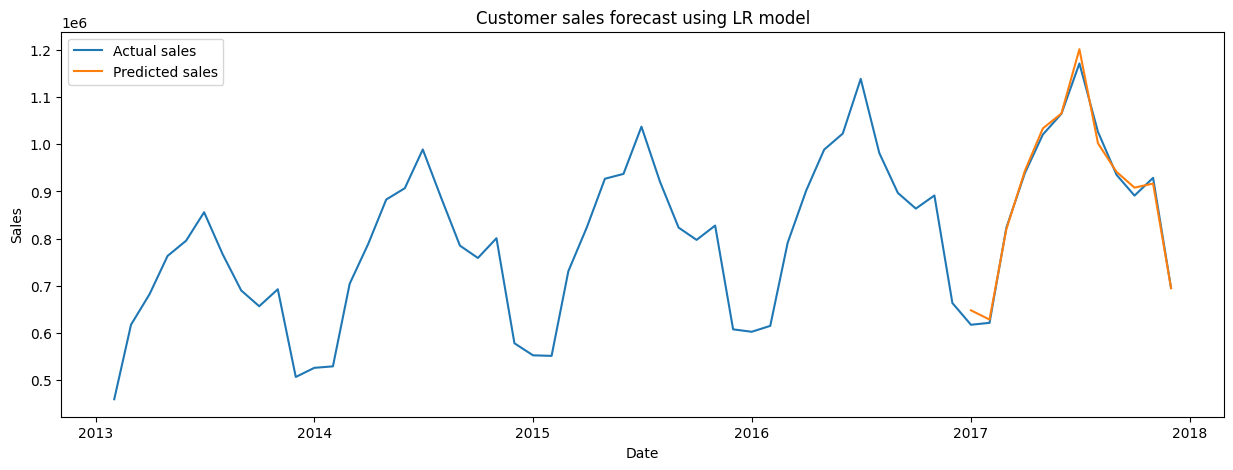

In [67]:
plt.figure(figsize=(15,5))
#actual sales
plt.plot(monthly_sales['date'],monthly_sales['sales'])
#predicted sales
plt.plot(predict_df['date'],predict_df['Linear prediction'])
plt.title("Customer sales forecast using LR model")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend(['Actual sales','Predicted sales'])
plt.show()